In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib as mpl

from scipy.stats import rayleigh
from scipy.stats import gaussian_kde


In [78]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [90]:
def get_ejected_initial_conditions_unordered(initial_df, final_df, mass):
    ejected_ids = final_df.loc[
        (final_df["mass"] == mass) &
        (final_df["result"] == "Ejected"),
        "particle_id"
    ].unique()

    return initial_df[
        initial_df["particle_id"].isin(ejected_ids)
    ].copy()

In [106]:
def power_law(m, A, alpha):
    return A * m**alpha

In [79]:
df_30=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187505_ejection_results.txt', header=None)
df_10=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187497_ejection_results.txt', header=None)
df_50=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187513_ejection_results.txt', header=None)

In [80]:
df_10

,0,1,2,3
0,0.010000,0.000000e+00,Captured,403
1,0.010000,0.000000e+00,Captured,196
2,0.010000,0.000000e+00,Captured,775
3,0.010000,0.000000e+00,Captured,296
4,0.010000,0.000000e+00,Captured,137
...,...,...,...,...
1701,0.000316,1.742140e+07,Ejected,616
1702,0.000316,1.754787e+07,Ejected,163
1703,0.000316,1.761110e+07,Ejected,70
1704,0.000316,1.789566e+07,Ejected,343


In [81]:
dfs=[df_10, df_30, df_50]
for df in dfs:
    df.columns = ['mass', 'time', 'result', 'particle_id']


In [82]:
ejection_df_30, capture_df_30 = compute_cumulative_outcome_fractions(df_30, df_30.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_10, capture_df_10 = compute_cumulative_outcome_fractions(df_10, df_10.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_50, capture_df_50 = compute_cumulative_outcome_fractions(df_50, df_50.mass.unique(), N=[800,800,800,800,800,800])

In [83]:
ejection_dfs=[ejection_df_10, ejection_df_30, ejection_df_50]
for ejection_df in ejection_dfs:
    ejection_df.sort_index(ascending=False, inplace=True)

In [84]:
r_min=0
r_max=125

In [85]:
a_arr = np.array([10, 30, 50])
for ejection_df, a in zip(ejection_dfs, a_arr):
    disc_fraction=3*a/(r_max-r_min)*ejection_df[ejection_df.columns[-1]]
    ejection_df['disc_fraction'] = disc_fraction

In [86]:
ejection_df_30[ejection_df_30.columns[-1]]

0.010000    0.3915
0.005012    0.3231
0.002512    0.2367
0.001259    0.2214
0.000631    0.1962
0.000316    0.1413
Name: disc_fraction, dtype: float64

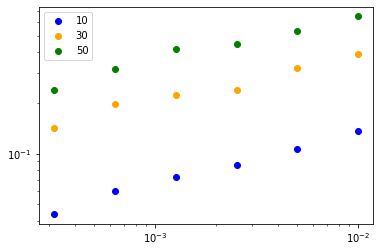

In [87]:
colors = ['blue', 'orange', 'green']
for ejection_df, color, a in zip(ejection_dfs, colors, a_arr):
    plt.scatter(ejection_df.index, ejection_df[ejection_df.columns[-1]], label=f'{a}', color=color)
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [93]:
job_ids = [2187497, 2187505, 2187513]   

In [125]:
df_is_list = []
df_fs=[]
for job_id in job_ids:
    df_is=[]
    


    for i in range(6):
        f=f'/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Particle_Tracking/{job_id}-{i}_initial_particles.txt'
        df=pd.read_csv(f, header=None)
        df.columns=['a','e','particle_id']

        df_is.append(df)
    f=f'/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/{job_id}_ejection_results.txt'
    df=pd.read_csv(f, header=None)
    df.columns=['mass','time','result','particle_id']

    df_fs.append(df)
    df_is_list.append(df_is)

6

In [97]:
df_f=df_10

In [98]:
masses=np.logspace(-2,-3.5, 6)

In [99]:
df_is

[             a         e  particle_id
 0     6.422535  0.130906            3
 1    20.363722  0.036145            1
 2    12.736978  0.162790            2
 3     8.816905  0.027565            0
 4    22.497037  0.064013            7
 ..         ...       ...          ...
 795  21.757943  0.162334          798
 796  20.968048  0.124848          796
 797  13.478730  0.199086          799
 798   5.649447  0.096562          793
 799  17.076654  0.085603          797
 
 [800 rows x 3 columns],
              a         e  particle_id
 0    13.286058  0.148376            0
 1    20.905698  0.253061            2
 2    10.284409  0.112719            3
 3    21.213802  0.038812            1
 4    12.174741  0.213612            7
 ..         ...       ...          ...
 795  22.561061  0.191550          780
 796  14.890226  0.090383          784
 797  14.606219  0.041442          788
 798  17.967223  0.118908          792
 799  12.799585  0.105118          796
 
 [800 rows x 3 columns],
          

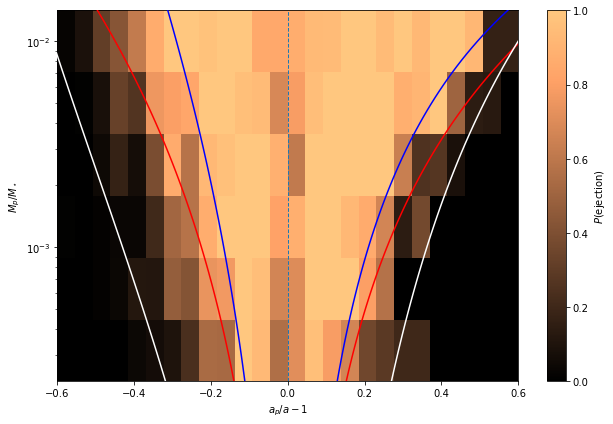

In [109]:



# ============================================================
# REDEFINED HERE
# ============================================================

a_planet = 10.0

# Your variable `masses` contains log10(mass).
# df_f["mass"] contains the actual mass.
mass_values = masses

# Keep the same number of bins that you previously had in a.


# Your chosen coordinate:
#
#     x = a_planet / a - 1
#
# Determine the x-range corresponding to the old a-range.

n_bins = 26          # MUST be odd
x_max = 0.6          # choose desired extent

x_edges = np.linspace(
    -x_max,
    x_max,
    n_bins + 1
)

x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])


# ============================================================
# CALCULATE EJECTION PROBABILITY IN EACH x BIN
# ============================================================

P = []

for mass, df_i in zip(mass_values, df_is):

    # Results corresponding to this planet mass
    final_df = df_f[
        np.isclose(df_f["mass"], mass)
    ]

    # Particle IDs that eventually ejected
    ejected_ids = final_df.loc[
        final_df["result"] == "Ejected",
        "particle_id"
    ].unique()

    df = df_i.copy()

    # Identify ejected particles
    df["ejected"] = df["particle_id"].isin(ejected_ids)

    # --------------------------------------------------------
    # IMPORTANT CHANGE:
    # Transform EACH PARTICLE to x before histogramming.
    # --------------------------------------------------------
    df["x"] = a_planet / df["a"] - 1


    # Number of all particles initially in each x bin
    N_all, _ = np.histogram(
        df["x"],
        bins=x_edges
    )

    # Number of ejected particles initially in each x bin
    N_ej, _ = np.histogram(
        df.loc[df["ejected"], "x"],
        bins=x_edges
    )
    

    # Probability of ejection
    p = np.divide(
        N_ej,
        N_all,
        out=np.full_like(
            N_ej,
            np.nan,
            dtype=float
        ),
        where=N_all > 0
    )

    P.append(p)


P = np.asarray(P)


# ============================================================
# SORT MASSES
# ============================================================

# pcolormesh is easiest to reason about with increasing y.
mass_order = np.argsort(mass_values)

mass_values = mass_values[mass_order]
P = P[mass_order, :]


# ============================================================
# DEFINE MASS-BIN EDGES
# ============================================================
#
# The masses are logarithmically spaced, so their visual
# boundaries should be halfway between them in log10 space.
# ============================================================

log_masses = np.log10(mass_values)

log_mass_edges = np.empty(len(log_masses) + 1)

# Interior edges
log_mass_edges[1:-1] = 0.5 * (
    log_masses[:-1] + log_masses[1:]
)

# Extrapolate first and last edges
log_mass_edges[0] = (
    log_masses[0]
    - 0.5 * (log_masses[1] - log_masses[0])
)

log_mass_edges[-1] = (
    log_masses[-1]
    + 0.5 * (log_masses[-1] - log_masses[-2])
)

mass_edges = 10**log_mass_edges


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))


mesh = ax.pcolormesh(
    x_edges,
    mass_edges,
    P,
    shading="flat",
    vmin=0,
    vmax=1,
    cmap="copper"
)

ax.set_yscale("log")

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel(r"$a_p/a - 1$")
ax.set_ylabel(r"$M_p/M_\star$")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$P(\mathrm{ejection})$")

plot_masses=np.logspace(-1, -4, 100)

HS_values=a_planet*(plot_masses/(3*(1+plot_masses)))**(1/3)
inv_HS_values_inner=a_planet/(a_planet-HS_values)-1
inv_HS_values_outer=a_planet/(a_planet+HS_values)-1

CZ_values_inner=1.2*(plot_masses**0.28*a_planet)
CZ_values_outer=1.7*(plot_masses**0.31*a_planet)

inv_CZ_values_inner=a_planet/(a_planet-CZ_values_inner)-1
inv_CZ_values_outer=a_planet/(a_planet+CZ_values_outer)-1

A_inner = 3.729132931366645
alpha_inner = 0.14939347354180882

A_outer = 34.508406515008886
alpha_outer = 0.32060397131882085
fit_outer=a_planet+2*power_law(plot_masses, A_outer, alpha_outer)
fit_inner=a_planet-2*power_law(plot_masses, A_inner, alpha_inner)

inv_fit_outer=a_planet/(fit_outer)-1
inv_fit_inner=a_planet/(fit_inner)-1

plt.plot(2*np.sqrt(3)*inv_HS_values_inner,plot_masses,  color='red', label='Hill Sphere', zorder=10)
plt.plot(2*np.sqrt(3)*inv_HS_values_outer,plot_masses,  color='red', label='Hill Sphere', zorder=10)
plt.plot(inv_CZ_values_inner,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
plt.plot(inv_CZ_values_outer,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
plt.plot(inv_fit_inner,plot_masses,  color='white', label='Power Law Fit', zorder=10)
plt.plot(inv_fit_outer,plot_masses,  color='white', label='Power Law Fit', zorder=10)

plt.tight_layout()
plt.xlim(-0.6,0.6)
plt.ylim(mass_edges.min(),mass_edges.max())
plt.show()

In [126]:
a_planets=[10, 30, 50]

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_63699/1690131638.py:210: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_63699/1690131638.py:210: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


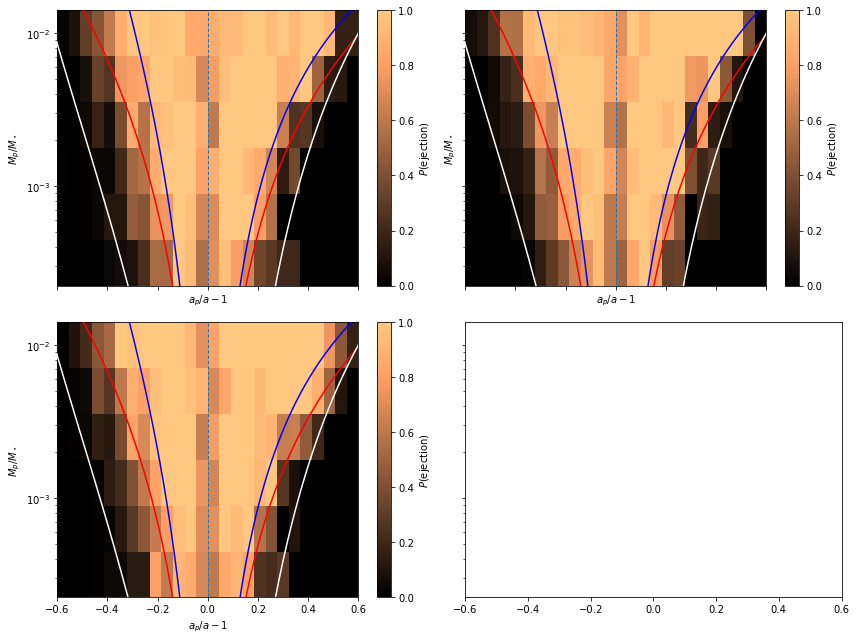

In [127]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, (ax, df_is, a_planet, df_f) in enumerate(zip(axes, df_is_list, a_planets, df_fs)):
        


    # ============================================================
    # REDEFINED HERE
    # ============================================================

    #a_planet = 10.0

    # Your variable `masses` contains log10(mass).
    # df_f["mass"] contains the actual mass.
    mass_values = masses

    # Keep the same number of bins that you previously had in a.


    # Your chosen coordinate:
    #
    #     x = a_planet / a - 1
    #
    # Determine the x-range corresponding to the old a-range.

    n_bins = 26          # MUST be odd
    x_max = 0.6          # choose desired extent

    x_edges = np.linspace(
        -x_max,
        x_max,
        n_bins + 1
    )

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])


    # ============================================================
    # CALCULATE EJECTION PROBABILITY IN EACH x BIN
    # ============================================================

    P = []

    for mass, df_i in zip(mass_values, df_is):

        # Results corresponding to this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # Particle IDs that eventually ejected
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        # Identify ejected particles
        df["ejected"] = df["particle_id"].isin(ejected_ids)

        # --------------------------------------------------------
        # IMPORTANT CHANGE:
        # Transform EACH PARTICLE to x before histogramming.
        # --------------------------------------------------------
        df["x"] = a_planet / df["a"] - 1


        # Number of all particles initially in each x bin
        N_all, _ = np.histogram(
            df["x"],
            bins=x_edges
        )

        # Number of ejected particles initially in each x bin
        N_ej, _ = np.histogram(
            df.loc[df["ejected"], "x"],
            bins=x_edges
        )
        

        # Probability of ejection
        p = np.divide(
            N_ej,
            N_all,
            out=np.full_like(
                N_ej,
                np.nan,
                dtype=float
            ),
            where=N_all > 0
        )

        P.append(p)


    P = np.asarray(P)


    # ============================================================
    # SORT MASSES
    # ============================================================

    # pcolormesh is easiest to reason about with increasing y.
    mass_order = np.argsort(mass_values)

    mass_values = mass_values[mass_order]
    P = P[mass_order, :]


    # ============================================================
    # DEFINE MASS-BIN EDGES
    # ============================================================
    #
    # The masses are logarithmically spaced, so their visual
    # boundaries should be halfway between them in log10 space.
    # ============================================================

    log_masses = np.log10(mass_values)

    log_mass_edges = np.empty(len(log_masses) + 1)

    # Interior edges
    log_mass_edges[1:-1] = 0.5 * (
        log_masses[:-1] + log_masses[1:]
    )

    # Extrapolate first and last edges
    log_mass_edges[0] = (
        log_masses[0]
        - 0.5 * (log_masses[1] - log_masses[0])
    )

    log_mass_edges[-1] = (
        log_masses[-1]
        + 0.5 * (log_masses[-1] - log_masses[-2])
    )

    mass_edges = 10**log_mass_edges


    # ============================================================
    # PLOT
    # ============================================================




    mesh = ax.pcolormesh(
        x_edges,
        mass_edges,
        P,
        shading="flat",
        vmin=0,
        vmax=1,
        cmap="copper"
    )

    ax.set_yscale("log")

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(r"$a_p/a - 1$")
    ax.set_ylabel(r"$M_p/M_\star$")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(r"$P(\mathrm{ejection})$")

    plot_masses=np.logspace(-1, -4, 100)

    HS_values=a_planet*(plot_masses/(3*(1+plot_masses)))**(1/3)
    inv_HS_values_inner=a_planet/(a_planet-HS_values)-1
    inv_HS_values_outer=a_planet/(a_planet+HS_values)-1

    CZ_values_inner=1.2*(plot_masses**0.28*a_planet)
    CZ_values_outer=1.7*(plot_masses**0.31*a_planet)

    inv_CZ_values_inner=a_planet/(a_planet-CZ_values_inner)-1
    inv_CZ_values_outer=a_planet/(a_planet+CZ_values_outer)-1

    A_inner = 3.729132931366645
    alpha_inner = 0.14939347354180882

    A_outer = 34.508406515008886
    alpha_outer = 0.32060397131882085
    fit_outer=a_planet+a_planet*power_law(plot_masses, A_outer, alpha_outer)/5
    fit_inner=a_planet-a_planet*power_law(plot_masses, A_inner, alpha_inner)/5

    inv_fit_outer=a_planet/(fit_outer)-1
    inv_fit_inner=a_planet/(fit_inner)-1

    ax.plot(2*np.sqrt(3)*inv_HS_values_inner,plot_masses,  color='red', label='Hill Sphere', zorder=10)
    ax.plot(2*np.sqrt(3)*inv_HS_values_outer,plot_masses,  color='red', label='Hill Sphere', zorder=10)
    ax.plot(inv_CZ_values_inner,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
    ax.plot(inv_CZ_values_outer,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
    ax.plot(inv_fit_inner,plot_masses,  color='white', label='Power Law Fit', zorder=10)
    ax.plot(inv_fit_outer,plot_masses,  color='white', label='Power Law Fit', zorder=10)

    plt.tight_layout()
    ax.set_xlim(-0.6,0.6)
    ax.set_ylim(mass_edges.min(),mass_edges.max())


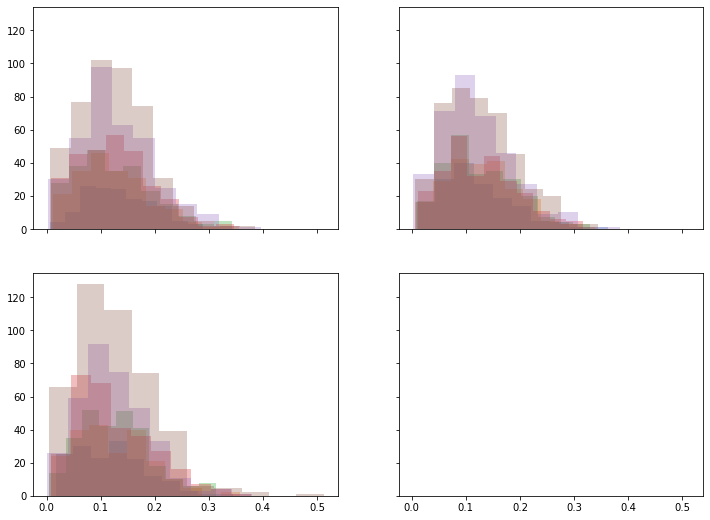

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, (ax, df_is, a_planet, df_f) in enumerate(zip(axes, df_is_list, a_planets, df_fs)):
    P = []
    
    for mass, df_i in zip(mass_values, df_is):

        # Results corresponding to this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # Particle IDs that eventually ejected
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        # Identify ejected particles
        df["ejected"] = df["particle_id"].isin(ejected_ids)
        e = df.loc[df["ejected"], "e"].dropna().to_numpy()

        color = cmap(norm(mass))

        # normalized histogram
        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            alpha=0.5
        )

        # Rayleigh fit to ejected population
        sigma_fit = rayleigh.fit(e, floc=0)[1]

        x = np.linspace(0, e.max(), 300)

        ax.plot(
            x,
            rayleigh.pdf(x, loc=0, scale=sigma_fit),
            color=color,
            linewidth=1.8
        )


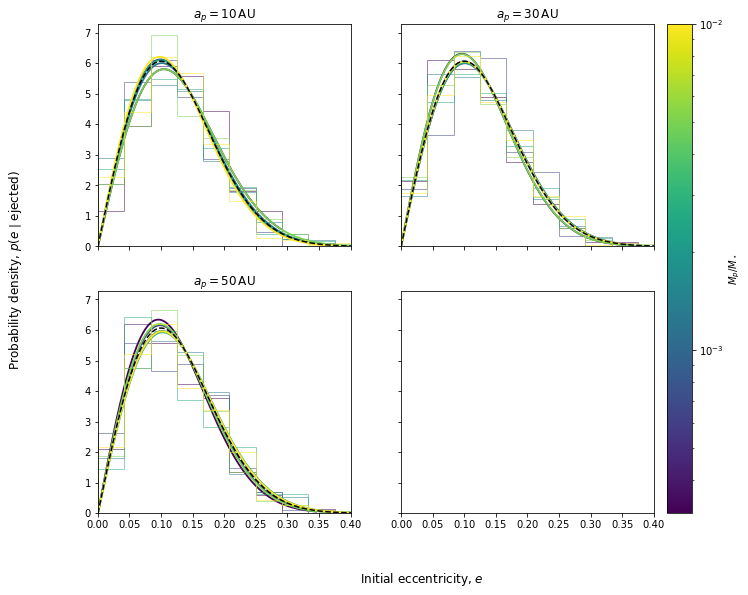

In [140]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

norm = mpl.colors.LogNorm(
    vmin=np.min(mass_values),
    vmax=np.max(mass_values)
)
cmap = plt.cm.viridis

bins = np.linspace(0, 1, 25)

for i, (ax, df_is, a_planet, df_f) in enumerate(
    zip(axes, df_is_list, a_planets, df_fs)
):
    

    for mass, df_i in zip(mass_values, df_is):

        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        df["ejected"] = df["particle_id"].isin(ejected_ids)

        e = df.loc[df["ejected"], "e"].dropna().to_numpy()

        color = cmap(norm(mass))

        # normalized histogram
        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            alpha=0.5
        )

        # Rayleigh fit to ejected population
        sigma_fit = rayleigh.fit(e, floc=0)[1]

        x = np.linspace(0, e.max(), 300)

        ax.plot(
            x,
            rayleigh.pdf(x, loc=0, scale=sigma_fit),
            color=color,
            linewidth=1.8
        )
        ax.set_xlim(0, 0.4)
    x = np.linspace(0, 0.5, 300)
    
    ax.plot(
        x,
        rayleigh.pdf(x, scale=0.1),
        "k--",
        linewidth=1.5,
        label=r"Initial Rayleigh, $\sigma=0.1$"
    )
    ax.set_title(fr"$a_p = {a_planet}\,\mathrm{{AU}}$")


fig.supxlabel(r"Initial eccentricity, $e$")
fig.supylabel(r"Probability density, $p(e\mid \mathrm{ejected})$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    pad=0.02
)
cbar.set_label(r"$M_p/M_\star$")


plt.show()

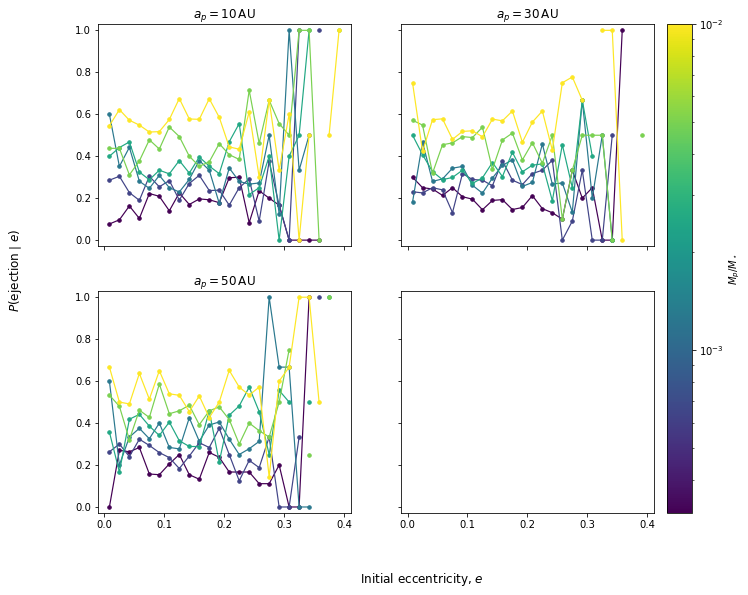

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

norm = mpl.colors.LogNorm(
    vmin=np.min(mass_values),
    vmax=np.max(mass_values)
)

cmap = plt.cm.viridis

# Same eccentricity bins for all panels/masses
e_bins = np.linspace(0, 0.4, 25)

for i, (ax, df_is, a_planet, df_f) in enumerate(
    zip(axes, df_is_list, a_planets, df_fs)
):

    for mass, df_i in zip(mass_values, df_is):

        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        df["ejected"] = df["particle_id"].isin(ejected_ids)

        # All initial particles in each eccentricity bin
        N_all, edges = np.histogram(
            df["e"],
            bins=e_bins
        )

        # Ejected particles in each eccentricity bin
        N_ejected, _ = np.histogram(
            df.loc[df["ejected"], "e"],
            bins=e_bins
        )

        # P(eject | e)
        p_eject = np.divide(
            N_ejected,
            N_all,
            out=np.full_like(
                N_ejected,
                np.nan,
                dtype=float
            ),
            where=N_all > 0
        )

        centers = 0.5 * (
            edges[:-1] + edges[1:]
        )

        ax.plot(
            centers,
            p_eject,
            marker="o",
            markersize=3.5,
            linewidth=1.2,
            color=cmap(norm(mass))
        )

    ax.set_title(
        fr"$a_p={a_planet}\,\mathrm{{AU}}$"
    )

    ax.set_ylim(-0.03, 1.03)


fig.supxlabel(r"Initial eccentricity, $e$")
fig.supylabel(
    r"$P(\mathrm{ejection}\mid e)$"
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    pad=0.02
)

cbar.set_label(r"$M_p/M_\star$")

plt.show()

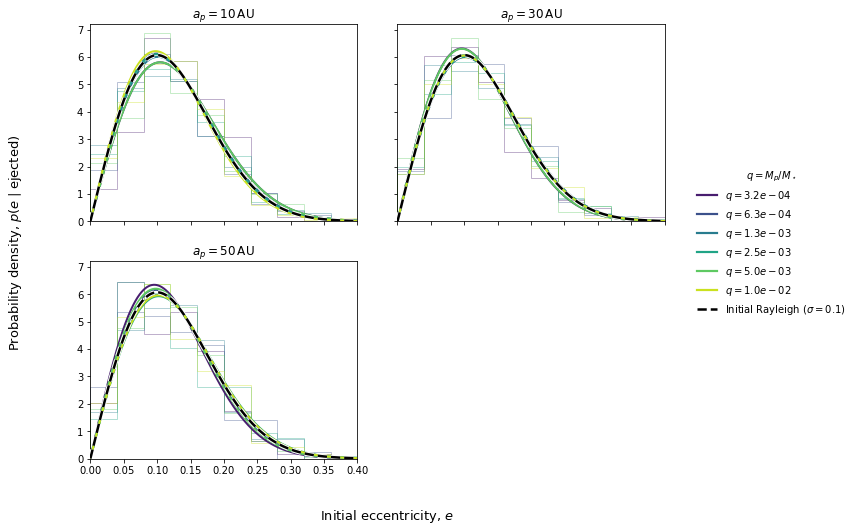

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from scipy.stats import rayleigh
from matplotlib.lines import Line2D


# --------------------------------------------------
# Plot settings
# --------------------------------------------------

sigma_initial = 0.1

bins = np.linspace(0, 0.4, 11)
x = np.linspace(0, 0.4, 500)

colors = plt.cm.viridis(
    np.linspace(0.08, 0.92, len(mass_values))
)


# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()


# --------------------------------------------------
# Panels
# --------------------------------------------------

for ax, df_is, a_planet, df_f in zip(
    axes,
    df_is_list,
    a_planets,
    df_fs
):

    for mass, df_i, color in zip(
        mass_values,
        df_is,
        colors
    ):

        # Final results for this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # IDs of ejected particles
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        # Initial conditions of particles that ejected
        df = df_i.copy()

        e = df.loc[
            df["particle_id"].isin(ejected_ids),
            "e"
        ].dropna().to_numpy()

        if len(e) < 2:
            continue

        # ------------------------------------------
        # Faint probability-density histogram
        # ------------------------------------------

        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            linewidth=1.0,
            alpha=0.35,
            zorder=1
        )

        # ------------------------------------------
        # Rayleigh fit
        # ------------------------------------------

        sigma_fit = rayleigh.fit(
            e,
            floc=0
        )[1]

        ax.plot(
            x,
            rayleigh.pdf(
                x,
                loc=0,
                scale=sigma_fit
            ),
            color=color,
            linewidth=2.0,
            zorder=3
        )


    # ----------------------------------------------
    # Original initial Rayleigh distribution
    # Draw this LAST so it remains visible
    # ----------------------------------------------

    initial_pdf = rayleigh.pdf(
        x,
        loc=0,
        scale=sigma_initial
    )

    initial_line, = ax.plot(
        x,
        initial_pdf,
        color="black",
        linestyle="--",
        linewidth=2.5,
        zorder=10
    )

    # White halo makes black line visible
    # even when curves lie directly underneath it
    initial_line.set_path_effects([
        pe.Stroke(
            linewidth=4.5,
            foreground="white"
        ),
        pe.Normal()
    ])

    ax.set_title(
        fr"$a_p = {a_planet}\,\mathrm{{AU}}$"
    )

    ax.set_xlim(0, 0.4)


# --------------------------------------------------
# Hide unused fourth panel
# --------------------------------------------------

for ax in axes[len(df_is_list):]:
    ax.set_visible(False)


# --------------------------------------------------
# Shared labels
# --------------------------------------------------

fig.supxlabel(
    r"Initial eccentricity, $e$",
    fontsize=13
)

fig.supylabel(
    r"Probability density, $p(e\mid\mathrm{ejected})$",
    fontsize=13
)


# --------------------------------------------------
# Custom discrete legend
# --------------------------------------------------

legend_handles = []

for mass, color in zip(mass_values, colors):

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.2,
            label=fr"$q={mass:.1e}$"
        )
    )

# Add initial distribution separately
legend_handles.append(
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=2.5,
        label=fr"Initial Rayleigh ($\sigma={sigma_initial}$)"
    )
)

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False,
    title=r"$q=M_p/M_\star$"
)


# Leave room for legend
fig.subplots_adjust(
    right=0.85,
    wspace=0.15,
    hspace=0.20
)

plt.show()